In [1]:
!pip install torch torchvision matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:17<00:00, 579kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.52MB/s]


In [5]:
print("Number of images:", len(dataset))

Number of images: 60000


In [15]:
image, label = dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


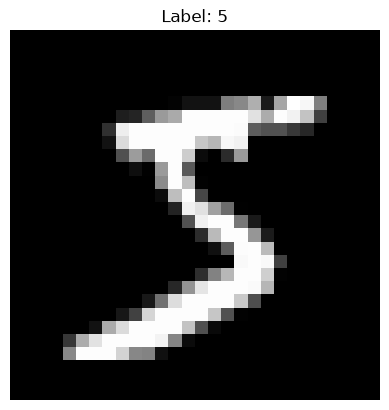

In [16]:
plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

| Parameter       | Meaning                   |
| --------------- | ------------------------- |
| `latent_dim`    | Size of random noise      |
| `image_size`    | 28 × 28 = 784 pixels      |
| `batch_size`    | Images processed together |
| `epochs`        | Number of training cycles |
| `learning_rate` | Speed of model learning   |


In [17]:
latent_dim = 100
image_size = 28 * 28
batch_size = 64
epochs = 10
learning_rate = 0.0002

In [19]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,image_size
            ),

            nn.Tanh()
        )

    def forward(self, x):

        x = self.model(x)

        return x.view(
            x.size(0),
            1,
            28,
            28
        )

In [21]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(image_size,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self, x):

        return self.model(x)

In [22]:
generator = Generator().to(device)

discriminator = Discriminator().to(device)

In [24]:
print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


In [25]:
criterion = nn.BCELoss()

In [26]:
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

In [27]:
noise = torch.randn(
    16,
    latent_dim,
    device=device
)

In [28]:
fake_images = generator(noise)

In [29]:
print(fake_images.shape)

torch.Size([16, 1, 28, 28])


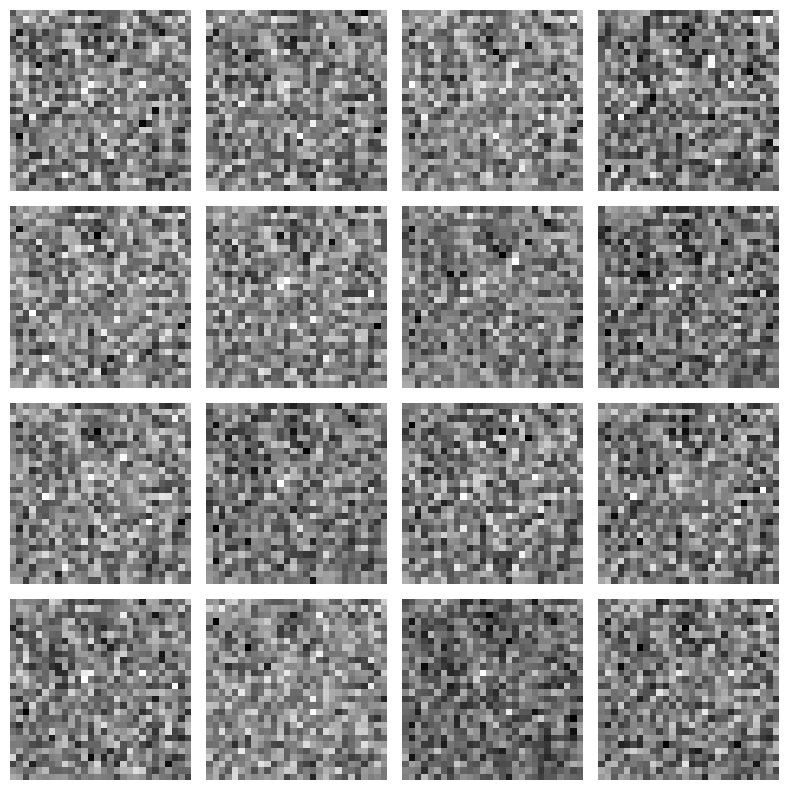

In [ ]:
fig, axes = plt.subplots(4,4,figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        fake_images[i].detach().cpu().squeeze(),
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
for epoch in range(epochs):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)

        batch_size_current = real_images.size(0)

        # =================================
        # Train Discriminator
        # =================================

        optimizer_D.zero_grad()

        # Real labels
        real_labels = torch.ones(
            batch_size_current,
            1,
            device=device
        )

        # Fake labels
        fake_labels = torch.zeros(
            batch_size_current,
            1,
            device=device
        )

        # -----------------------------
        # Real images
        # -----------------------------

        real_output = discriminator(
            real_images
        )

        loss_real = criterion(
            real_output,
            real_labels
        )

        # -----------------------------
        # Fake images
        # -----------------------------

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_images = generator(noise)

        fake_output = discriminator(
            fake_images.detach()
        )

        loss_fake = criterion(
            fake_output,
            fake_labels
        )

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        # Backpropagation
        loss_D.backward()

        # Update discriminator
        optimizer_D.step()


        # =================================
        # Train Generator
        # =================================

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_images = generator(noise)

        fake_output = discriminator(
            fake_images
        )

        # Generator wants fake images
        # to be classified as REAL
        loss_G = criterion(
            fake_output,
            real_labels
        )

        # Backpropagation
        loss_G.backward()

        # Update generator
        optimizer_G.step()


    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Generator Loss: {loss_G.item():.4f} "
        f"Discriminator Loss: {loss_D.item():.4f}"
    )

Epoch [1/10] Generator Loss: 4.4243 Discriminator Loss: 0.5464
Epoch [2/10] Generator Loss: 3.9837 Discriminator Loss: 0.2020
Epoch [3/10] Generator Loss: 5.1107 Discriminator Loss: 0.0373
Epoch [4/10] Generator Loss: 5.1639 Discriminator Loss: 0.1478
Epoch [5/10] Generator Loss: 2.3966 Discriminator Loss: 0.2750
Epoch [6/10] Generator Loss: 5.8471 Discriminator Loss: 0.0137
Epoch [7/10] Generator Loss: 7.4782 Discriminator Loss: 0.0011
Epoch [8/10] Generator Loss: 10.1071 Discriminator Loss: 0.0000
Epoch [9/10] Generator Loss: 11.0698 Discriminator Loss: 0.0000
Epoch [10/10] Generator Loss: 11.6791 Discriminator Loss: 0.0000


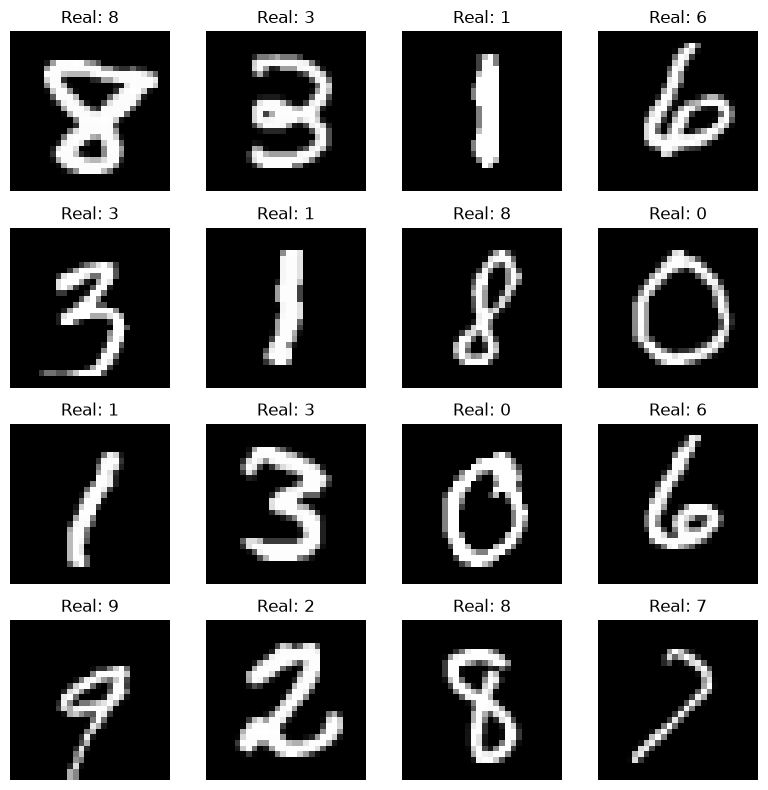

In [32]:
real_images, labels = next(
    iter(dataloader)
)

fig, axes = plt.subplots(4,4,figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        real_images[i].squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"Real: {labels[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

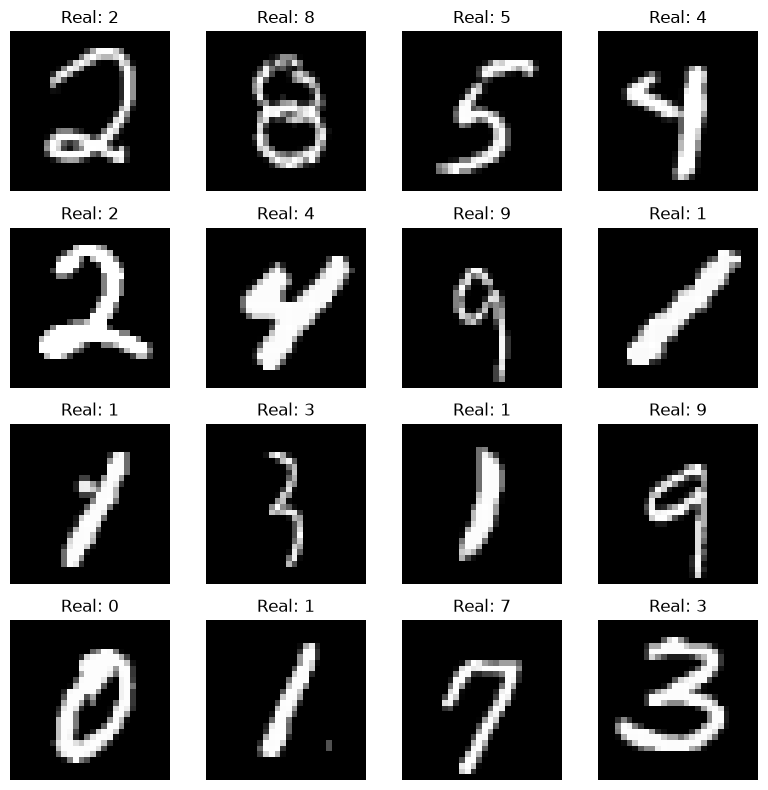

In [33]:
real_images, labels = next(
    iter(dataloader)
)

fig, axes = plt.subplots(4,4,figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        real_images[i].squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"Real: {labels[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
torch.save(
    generator.state_dict(),
    "generator.pth"
)

In [35]:
torch.save(
    discriminator.state_dict(),
    "discriminator.pth"
)

Load the Generator

In [36]:
generator = Generator().to(device)

generator.load_state_dict(
    torch.load(
        "generator.pth",
        map_location=device
    )
)

generator.eval()

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Tanh()
  )
)